# 01. 소리 데이터 탐색

MIMII 데이터셋의 소리 파일을 불러와서 어떻게 생겼는지 확인한다.

**먼저 할 일**
1. https://zenodo.org/records/3384388 에서 `6_dB_slider.zip` 다운로드
2. 압축을 풀어서 `data/` 폴더 안에 넣기 (예: `data/slider/id_00/normal/00000000.wav`)
3. 라이브러리 설치: `pip install librosa matplotlib numpy`

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np

In [2]:
# 소리 파일 1개 불러오기 (다운로드 후 실제 경로에 맞게 수정)
file_path = '../data/slider/id_00/normal/00000000.wav'

y, sr = librosa.load(file_path, sr=None)

print('샘플링 레이트 :', sr)
print('데이터 길이   :', len(y))
print('재생 시간(초) :', len(y) / sr)

샘플링 레이트 : 16000
데이터 길이   : 160000
재생 시간(초) : 10.0


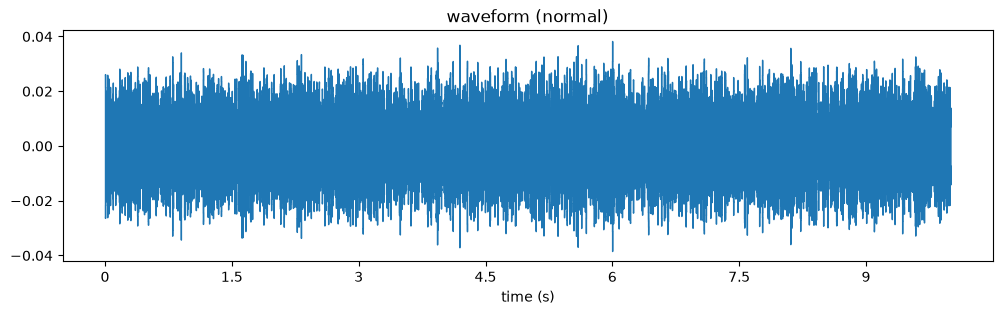

In [3]:
# 파형 그려보기 (시간에 따른 소리의 크기)
plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr)
plt.title('정상 파형')
plt.xlabel('시간 (초)')
plt.show()

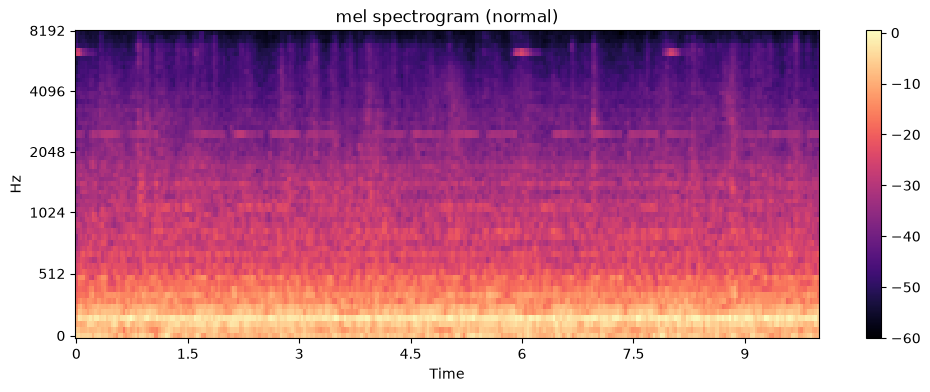

In [4]:
# 멜 스펙트로그램 그려보기 (소리를 이미지처럼 표현 -> CNN 입력으로 사용)
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
mel_db = librosa.power_to_db(mel)

plt.figure(figsize=(12, 4))
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar()
plt.title('정상 멜 스펙트로그램')
plt.show()

## 다음 단계

- (선택) 다른 기계 id_02, id_04, id_06도 같은 방법으로 비교해보기 — 경로의 `id_00`만 바꾸면 된다
- (선택) `file_names` 리스트의 파일 이름을 바꿔서 다른 파일들도 비교해보기
- 다음 노트북(02)에서는 **모든 파일을 멜 스펙트로그램으로 변환하는 전처리**를 만든다 (진행 계획 2단계)

In [12]:
# 정상 파일 1개, 이상 파일 1개 불러오기
normal_path = '../data/slider/id_02/normal/00000000.wav'
abnormal_path = '../data/slider/id_02/abnormal/00000000.wav'

y_normal, sr = librosa.load(normal_path, sr=None)
y_abnormal, sr = librosa.load(abnormal_path, sr=None)

print('정상 소리 길이(초) :', len(y_normal) / sr)
print('이상 소리 길이(초) :', len(y_abnormal) / sr)

정상 소리 길이(초) : 10.0
이상 소리 길이(초) : 10.0


In [13]:
# 소리 직접 들어보기 (스피커/이어폰 필요)
from IPython.display import Audio, display

print('정상 소리')
display(Audio(y_normal, rate=sr))

print('이상 소리')
display(Audio(y_abnormal, rate=sr))

정상 소리


이상 소리


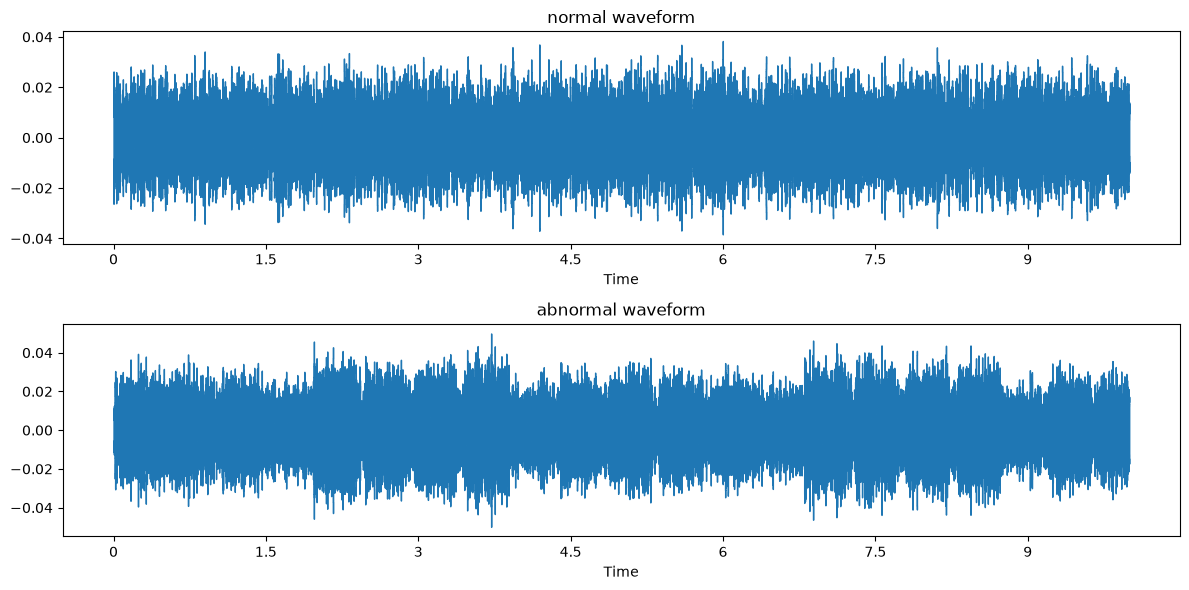

In [7]:
# 파형 비교: 위 = 정상, 아래 = 이상
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)  # 2행 1열 중 1번째
librosa.display.waveshow(y_normal, sr=sr)
plt.title('정상 파형')

plt.subplot(2, 1, 2)  # 2행 1열 중 2번째
librosa.display.waveshow(y_abnormal, sr=sr)
plt.title('이상 파형')

plt.tight_layout()
plt.show()

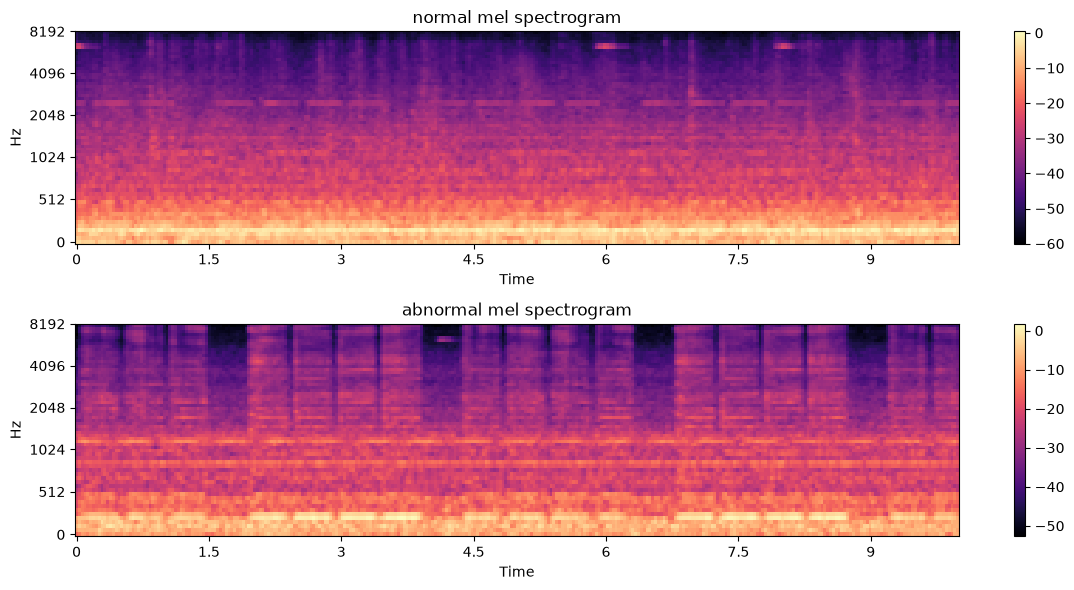

In [8]:
# 멜 스펙트로그램 비교: 위 = 정상, 아래 = 이상
mel_normal = librosa.feature.melspectrogram(y=y_normal, sr=sr, n_mels=64)
mel_normal_db = librosa.power_to_db(mel_normal)

mel_abnormal = librosa.feature.melspectrogram(y=y_abnormal, sr=sr, n_mels=64)
mel_abnormal_db = librosa.power_to_db(mel_abnormal)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)  # 2행 1열 중 1번째
librosa.display.specshow(mel_normal_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar()
plt.title('정상 멜 스펙트로그램')

plt.subplot(2, 1, 2)  # 2행 1열 중 2번째
librosa.display.specshow(mel_abnormal_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar()
plt.title('이상 멜 스펙트로그램')

plt.tight_layout()
plt.show()

## 여러 파일로 확인하기

파일 1개의 차이는 우연일 수 있다. 정상 3개, 이상 3개를 한 번에 그려서
패턴이 일관적인지 확인한다.

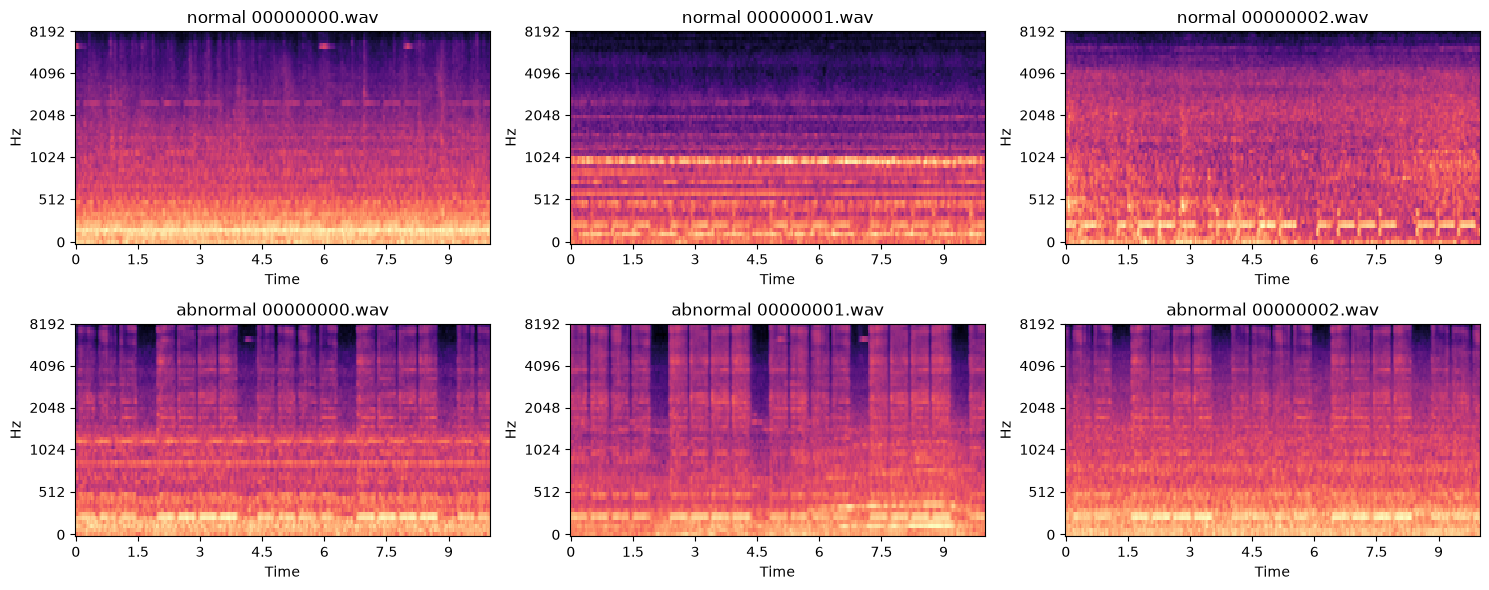

In [9]:
# 정상 3개(윗줄), 이상 3개(아랫줄) 멜 스펙트로그램 비교
file_names = ['00000000.wav', '00000001.wav', '00000002.wav']

plt.figure(figsize=(15, 6))

# 윗줄: 정상 3개
for i in range(3):
    y_tmp, sr = librosa.load('../data/slider/id_00/normal/' + file_names[i], sr=None)
    mel_tmp = librosa.feature.melspectrogram(y=y_tmp, sr=sr, n_mels=64)
    mel_tmp_db = librosa.power_to_db(mel_tmp)

    plt.subplot(2, 3, i + 1)  # 2행 3열 중 1~3번째 칸
    librosa.display.specshow(mel_tmp_db, sr=sr, x_axis='time', y_axis='mel')
    plt.title('정상 ' + file_names[i])

# 아랫줄: 이상 3개
for i in range(3):
    y_tmp, sr = librosa.load('../data/slider/id_00/abnormal/' + file_names[i], sr=None)
    mel_tmp = librosa.feature.melspectrogram(y=y_tmp, sr=sr, n_mels=64)
    mel_tmp_db = librosa.power_to_db(mel_tmp)

    plt.subplot(2, 3, i + 4)  # 2행 3열 중 4~6번째 칸
    librosa.display.specshow(mel_tmp_db, sr=sr, x_axis='time', y_axis='mel')
    plt.title('이상 ' + file_names[i])

plt.tight_layout()
plt.show()

## 관찰 정리

- **정상**: 저주파(아래쪽)에 밝은 가로 띠가 규칙적으로 유지된다 (기계가 일정하게 가동되는 소리).
- **이상**: 그 위에 세로 줄무늬·불규칙한 밝은 얼룩이 추가로 나타난다 (정상에는 없던 성분).
- 귀로 들어도 이상 쪽에서 규칙적인 소리에 덜컹거림/긁힘 같은 잡음이 섞여 들린다.
- → 이 "정상에는 없던 패턴"을 정상만 학습한 AutoEncoder가 복원하지 못해 이상으로 잡는다 (03~04단계의 근거).

## 해볼 것

- `normal` 폴더와 `abnormal` 폴더의 소리를 각각 그려서 눈으로 비교해보기
- 정상과 이상의 스펙트로그램이 어디가 다른지 관찰하기

다음 노트북(02)에서는 모든 파일을 스펙트로그램으로 변환하는 전처리를 만든다.